# Material for the chapter: Diffusion model

In [1]:
%matplotlib inline
import internal_script
import dorion_francois.dfbook as df # path utils (etc.) for the book

# Defines T, dt, n_days, and the figureXX functions among others
from dorion_francois.diffusion_model import *

seed = 8628


We consider an UA traded in continuous time on an arbitrage-free financial
market. The market price of the UA is a stochastic process $\left(
S_{t}\right)_{t\geq 0}$ that we aim to characterize. We focus our attention
on the time interval $\left[ t,t+1\right] $ that we discretize into $n$
periods of equal length $h$. Let $\left( z_{u}\right) _{u\geq 0}$ denote the
stochastic process representing the UA return and $\Delta _{h}z$ denote the
change in UA return over the time period $h$, that is
\begin{equation*}
\Delta_{h}z=z_{t+ih}-z_{t+\left( i-1\right) h}\qquad\forall
i=1,...,n.
\end{equation*}
The figure below displays the time discretization of the interval $\left[
t,t+1\right] $. 

### Figure 1 of the chapter

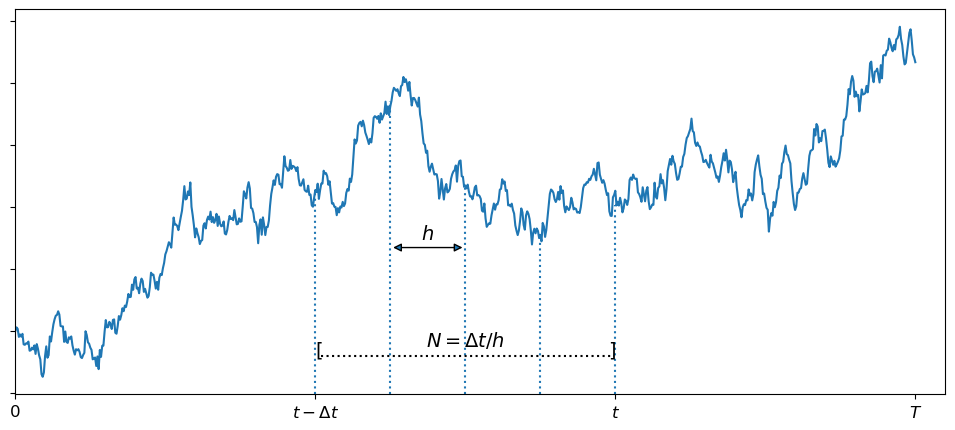

In [2]:
time = np.arange(0,T+dt,dt) # The "end" is not included in Python arrays
dz = np.random.randn(n_days,1)*np.sqrt(dt)
z_0 = 0
z_t = np.cumsum( np.insert(dz, 0, z_0, axis=0) )
figure01(time, z_t)
df.savefig('diffusion','fig_example_brownian_motion.pdf')

Let $\Lambda $ denote the set of "step" functions from $\mathbb{R}^{+}$ to $\mathbb{R}$, i.e. all functions $f_{n}$ that can be written as 
\begin{equation*}
f_{n}\left( t\right) =\sum_{i=1}^{n}a_{i}1_{\left] t_{i},t_{i+1}\right]
}\left( t\right) .
\end{equation*}
These functions can be represented as follows 

### Figure 2 of the chapter

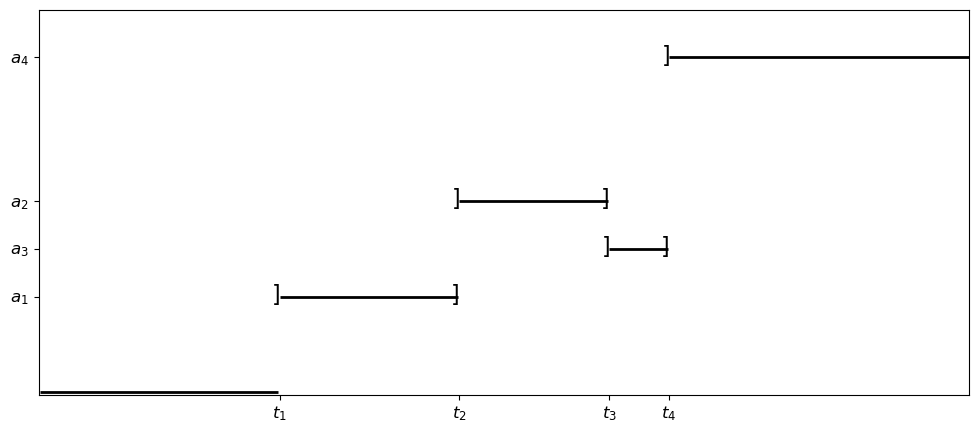

In [3]:
t_values = np.array([0.8, 1.4, 1.9, 2.1, 3.5])
a_values = np.array([0, 2, 4, 3, 7])
figure02(t_values, a_values)
df.savefig('diffusion','fig_step_function.pdf')

## Additional material

### Properties of the Brownian motion

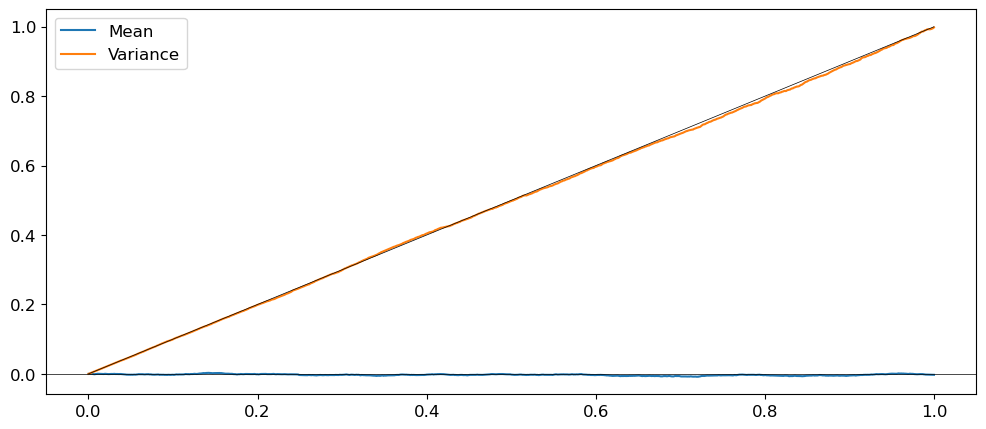

In [4]:
# Local overrides to diffusion_model variables
T = 1
N = 1000 
dt = 1/N
n_paths = 10000 

time = np.arange(0,T+dt,dt) # The "end" is not included in Python arrays
dz = np.random.randn(N,n_paths)*np.sqrt(dt)
z_t = np.cumsum(np.vstack((np.zeros((1,n_paths)),dz)), axis=0)

mean_t = np.mean(z_t, axis=1)
var_t = np.var(z_t, axis=1)
fig, ax = plt.subplots(1, 1, figsize=(12,5))
ax.plot(time, mean_t, label='Mean')
ax.plot(time, var_t, label='Variance')
ax.plot(time,time,color='k',lw=0.5)
ax.axhline(y=0,color='k',lw=0.5)
ax.legend(loc='upper left'); # Last line of cell will print result without ;

Can you generate similar figures for the generalized Brownian motion? The geometric Brownian motion? 

### Some informal intuition behind the Girsanov theorem from an asset pricing standpoint

Consider an asset whose dynamics is given by
\begin{align}
\frac{dS}{S} 
&= \mu dt + \sigma dW^{\mathbb{P}}.
\end{align}
Defining a constant $\eta = (\mu - r) / \sigma$, the above is equivalent to
\begin{align}
\frac{dS}{S} 
&= r dt + \sigma \left(dW^{\mathbb{P}} + \eta dt\right).
\end{align}
That is, under the physical measure, the drift embeds a risk premium $\eta\sigma$, i.e. $\mu = r + \eta \sigma$. This means that, compared to an asset that would yield the risk-free rate, instantaneous shocks on $S$ can be view as being translated by $\eta dt$. The code below illustrates this intuition.

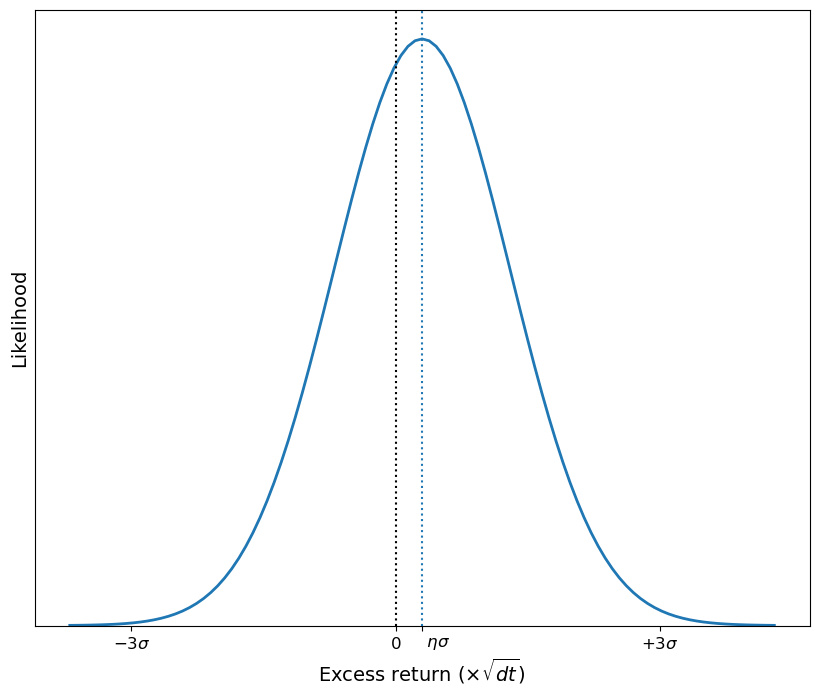

In [5]:
import scipy.stats as stats

dt = 1 # For illustration purposes, this makes it simpler. 
eta = 0.3
sigma = 0.2
sigma_h = sigma*np.sqrt(dt) # Stdev over (h)orizon dt
dWP = np.linspace(-4*np.sqrt(dt), +4*np.sqrt(dt), 101)
dP = stats.norm.pdf(dWP, 0, np.sqrt(dt))

dSS_minus_rdt = sigma*(dWP+eta*dt)

def excess_returns():
    fig, ax = plt.subplots(1, 1, figsize=(10,8))
    #ax.set_title()
 
    line = ax.plot(dSS_minus_rdt, dP, lw=2, label='Under P');
    ax.axvline(sigma*eta*dt,color=line[0].get_color(),ls=':')
    ax.axvline(0,color='k',ls=':')
    ax.set_xticks([-3*sigma_h, 0, eta*sigma_h, +3*sigma_h])
    ax.set_xticklabels([
        '$-3\sigma$', '$0$', '$\qquad\eta\sigma$', '$+3\sigma$'])
    ax.set_xlabel('Excess return ($\\times \sqrt{dt}$)')

    ax.set_ylim((0, ax.get_ylim()[1]))
    ax.set_yticks([])
    ax.set_ylabel('Likelihood')
    
    return ax
excess_returns();

Under $\mathbb{Q}$, the compensation for risk disappears, **not** because we assume risk-neutrality, but because we "hide" the risk-adjustement in the *distribution* of the excess return, overweighing negative excess returns, and underweighing positive ones, using the "likelihood ratio":

\begin{align}
    \left.\frac{d\mathbb{Q}}{d\mathbb{P}}\right|_{\mathcal{F}(t)}
     = exp\Big\lbrace
    -\int_0^t \eta(u)d{W(u)} - \frac{1}{2}\int_0^t \eta^2(u)d{u} 
    \Big\rbrace
\end{align}

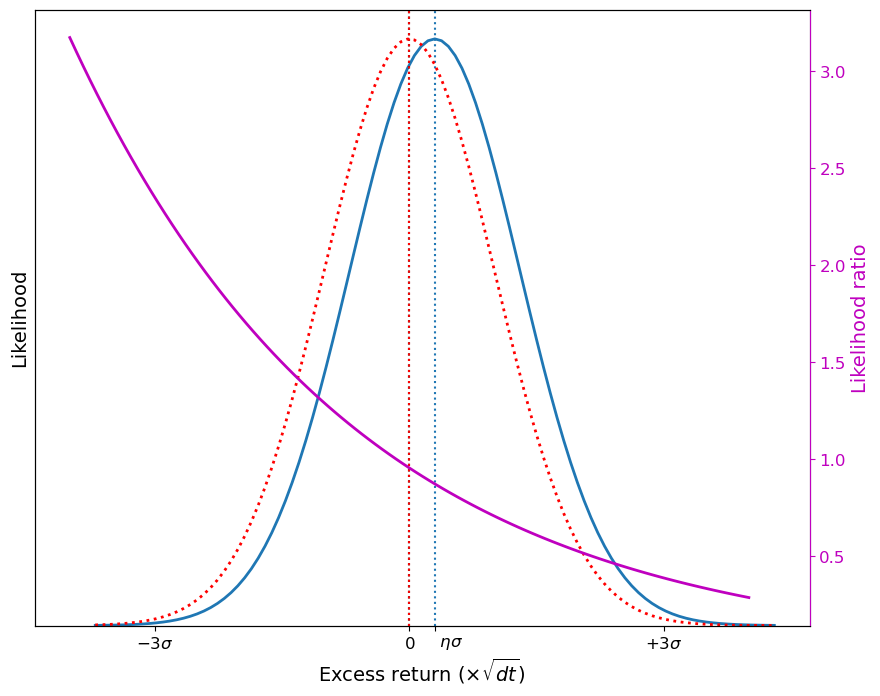

In [6]:
# Between times t and (t+dt), the integrals in the change of measure accumulate a "single"
# (infinitesimal) increment
dQ_dP = np.exp(-eta*dWP - 0.5*(eta**2)*dt)

def change_of_measure():
    ax = excess_returns()
    ax2 = ax.twinx()
    ax2.plot(sigma*dWP, dQ_dP, color='m', lw=2)
    ax2.set_ylabel('Likelihood ratio')
    ax2.yaxis.label.set_color('m')
    ax2.spines["right"].set_edgecolor('m')
    ax2.tick_params(axis='y', colors='m')

    ax.plot(dSS_minus_rdt, dQ_dP*dP, color='r', ls=':', lw=2)
    ax.axvline(0,color='r',ls=':')
    return ax
change_of_measure();

Note how the red dashed line in the above graph is created by simply multiplying dP by the likelihood ratio (line 11 of the previous code cell). Yet it "looks" very much like a normal density. Essentially, the Girsanov theorem states that it **is** a normal density, that is, 
$d\mathbb{Q} \equiv \frac{d\mathbb{Q}}{d\mathbb{P}} \times d\mathbb{P}$ is a proper probability measure and
\begin{align}
dW^{\mathbb{Q}} = dW^{\mathbb{P}} + \eta dt
\end{align}
is a Brownian motion under $d\mathbb{Q}$.

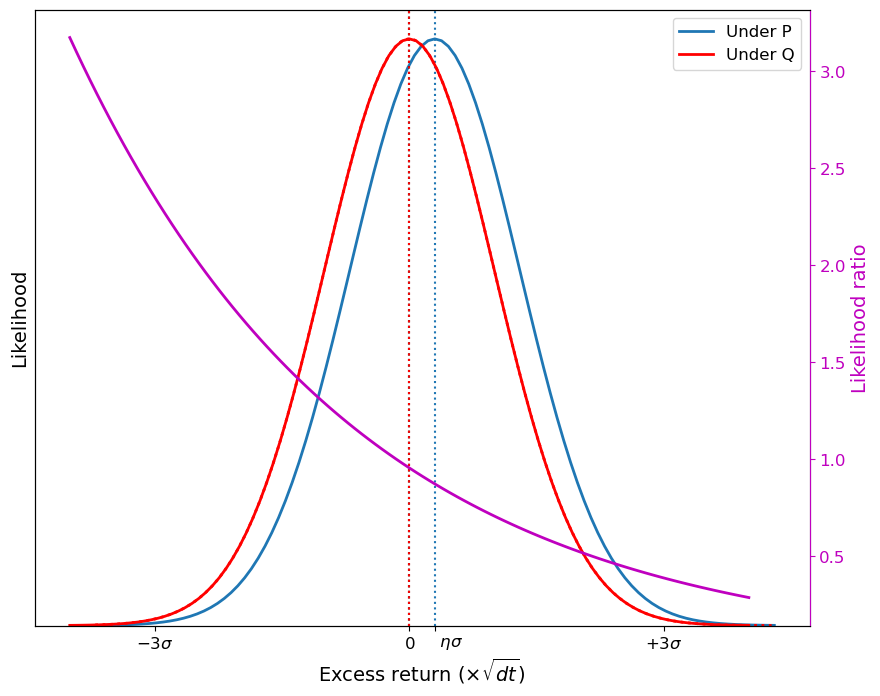

In [7]:
dWQ = np.linspace(-4*np.sqrt(dt), +4*np.sqrt(dt), 101)
dQ = stats.norm.pdf(dWQ, 0, np.sqrt(dt))

ax = change_of_measure()
ax.plot(sigma*dWQ, dQ, color='r', lw=2, label='Under Q')
ax.legend(loc='upper right');
df.savefig('diffusion','fig_diffusion_s01.pdf')

As you can see, the $d\mathbb{Q}$ (`dQ` in the code) red line, defined as the normal density of $dW^{\mathbb{Q}}$ (`dWQ`) perfectly superimposes with the previous dotted red line that graphed `dQ_dP\*dP` as a function of the physical excess returns.